<a href="https://colab.research.google.com/github/Ashitharaj12/python_examples/blob/ashitha/FNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predict energy ***consumption***

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load Dataset
data = pd.read_csv("predict_energy_consumption.csv")

In [3]:
# Select features (X) and target variable (y)
X = data.drop(columns=["energy_consumption"])
y = data["energy_consumption"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 5. Scale the data for better performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# 6. Build the FNN Model
# a. Initialize the model
model = Sequential()

# b. Input layer
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

# c. Hidden layers
model.add(Dense(1, activation='linear'))  # Use 'sigmoid' or 'softmax' for classification tasks

# d. Output layer (for regression tasks)
model.add(Dense(1, activation='linear'))  # Use 'sigmoid' or 'softmax' for classification tasks

# e. Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# 7. Train the Model

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # Use part of the training set for validation
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 89941.9609 - mae: 271.9159 - val_loss: 83936.3125 - val_mae: 259.4915
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 88763.0156 - mae: 268.4155 - val_loss: 83656.1875 - val_mae: 258.9478
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 90629.1250 - mae: 270.9499 - val_loss: 83348.7031 - val_mae: 258.3501
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 88916.0234 - mae: 268.5971 - val_loss: 83009.3516 - val_mae: 257.6893
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 89274.0703 - mae: 269.2261 - val_loss: 82624.2656 - val_mae: 256.9383
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 84093.4531 - mae: 260.4476 - val_loss: 82187.0859 - val_mae: 256.0820
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 87411.0625 - mae: 265.8429 - val_loss: 81682.4531 - val_mae: 255.0899
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 88976.9922 - mae: 267.9967 - val_loss: 81100.7

In [8]:
# 8. Evaluate the Model
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19242.8516 - mae: 118.5455 
Test Loss: 19050.921875, Test MAE: 117.84699249267578


In [9]:
# 9. Make Predictions
predictions = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [10]:
# 10. Display the first few predictions
print("Predictions:", predictions[:5])
print("Actual Values:", y_test[:5].values)

Predictions: [[269.8516 ]
 [211.87477]
 [244.05258]
 [198.19994]
 [336.8752 ]]
Actual Values: [309.70268707 206.97435836 373.42315097 280.00113732  51.88434963]


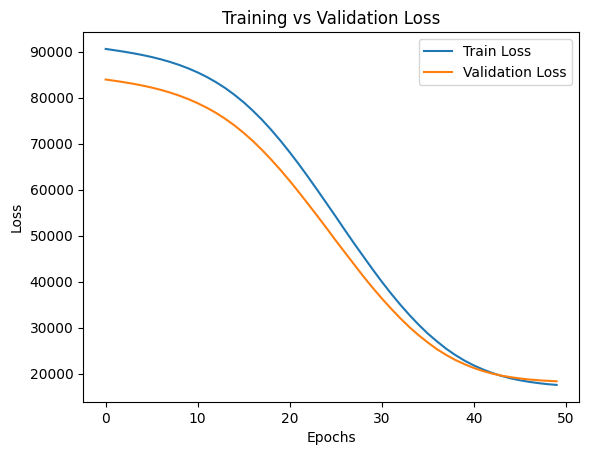

In [11]:
# 11. Visualize Training History
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()